# Model Comparison: CNN10 vs CNN12, with/without Synthetic Data
## Compare 8 configurations across 2 test sets (13b and 14a).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, roc_auc_score, confusion_matrix, classification_report
)

## 1. Load all result CSVs
Each CSV should have columns: `prob_neg`, `prob_pos`, `y_true`

In [ ]:
experiments = {
    "CNN10 + synth / 13b":   "../output/results/predictions/cnn10/all/13b_cnn10eval_file_probs.csv",
    "CNN10 + synth / 14a":   "../output/results/predictions/cnn10/all/14a_cnn10eval_file_probs.csv",
    "CNN10 no synth / 13b":  "../output/results/predictions/cnn10/mefou/13b_cnn10eval_file_probs.csv",
    "CNN10 no synth / 14a":  "../output/results/predictions/cnn10/mefou/14a_cnn10eval_file_probs.csv",
    "CNN12 + synth / 13b":   "../output/results/predictions/cnn12/all/13b_cnn12eval_file_probs.csv",
    "CNN12 + synth / 14a":   "../output/results/predictions/cnn/all/14a_cnn12eval_file_probs.csv",
    "CNN12 no synth / 13b":  "../output/results/predictions/cnn12/mefou/13b_cnn12eval_file_probs.csv",
    "CNN12 no synth / 14a":  "../output/results/predictions/cnn12/mefou/14a_cnn12eval_file_probs.csv",
    "SVM + synth / 13b":  [
        "../output/results/predictions/svm/all/sample_13b_1_predictions.txt",
        "../output/results/predictions/svm/all/sample_13b_1_y_test.csv",
        "../output/results/predictions/svm/all/13b_1_frame-info.csv",
    ],
    "SVM + synth / 14a":  [
        "../output/results/predictions/svm/all/sample_14a_predictions.txt",
        "../output/results/predictions/svm/all/sample_14a_y_test.csv",
        "../output/results/predictions/svm/all/14a_frame-info.csv",
    ],
        "SVM no synth / 13b":  [
        "../output/results/predictions/svm/mefou/sample_13b_1_predictions.txt",
        "../output/results/predictions/svm/mefou/sample_13b_1_y_test.csv",
        "../output/results/predictions/svm/mefou/13b_1_frame-info.csv",
    ],
    "SVM no synth / 14a":  [
        "../output/results/predictions/svm/mefou/sample_14a_predictions.txt",
        "../output/results/predictions/svm/mefou/sample_14a_y_test.csv",
        "../output/results/predictions/svm/mefou/14a_frame-info.csv",
    ],
}

In [3]:
experiments['SVM + synth / 13b']

['../results/predictions/svm/all/sample_13b_1_predictions.txt',
 '../results/predictions/svm/all/sample_13b_1_y_test.csv',
 '../results/predictions/svm/all/13b_1_frame-info.csv']

In [ ]:
from numpy import loadtxt

def read_preds(pred_file):
    preds = pd.read_csv(pred_file, header=None, names=["pred_label"])
    print(
        f"Loaded {len(preds)} predictions from {pred_file} "
        f"of type {type(preds)} and shape {preds.shape}"
    )
    print(f"Missing values in preds: {preds.isna().sum()}")
    return preds

def read_true(true_file):
    y_true = pd.read_csv(true_file, header=0)
    print(
        f"Loaded {len(y_true)} true labels from {true_file} "
        f"of type {type(y_true)} and shape {y_true.shape}"
    )
    print(f"Missing values in y_true: {y_true.isna().sum()}")
    print(f"First value in y_true: {y_true.iloc[0]}")
    return y_true

def read_frame_info(frame_info_file):
    frame_info = pd.read_csv(frame_info_file)
    print(
        f"Loaded {len(frame_info)} frame rows from {frame_info_file} "
        f"with {frame_info['file_path'].nunique()} unique audio files"
    )
    return frame_info

def load_svm_predictions(paths, file_threshold):
    """Aggregate SVM chunk predictions to one row per audio file."""
    pred_file, true_file, frame_info_file = paths

    preds = read_preds(pred_file)
    y_true = read_true(true_file)
    frame_info = read_frame_info(frame_info_file)

    if not (len(preds) == len(y_true) == len(frame_info)):
        raise ValueError(
            "SVM predictions, labels, and frame info must have the same number of rows. "
            f"Got {len(preds)=}, {len(y_true)=}, {len(frame_info)=}"
        )

    label_map = {"background": 0, "chimpanze": 1}
    chunk_df = frame_info[["file_path"]].copy()
    chunk_df["preds"] = preds["pred_label"].map(label_map)
    chunk_df["y_true"] = y_true.iloc[:, 0].map(label_map)

    if chunk_df[["preds", "y_true"]].isna().any().any():
        raise ValueError("Unexpected SVM label encountered while mapping predictions.")

    file_df = (
        chunk_df.groupby("file_path", as_index=False)
        .agg(
            prob_pos=("preds", "mean"),
            true_pos_rate=("y_true", "mean"),
            n_chunks=("preds", "size"),
        )
    )
    file_df["prob_neg"] = 1 - file_df["prob_pos"]
    file_df["preds"] = (file_df["prob_pos"] >= file_threshold).astype(int)
    file_df["y_true"] = (file_df["true_pos_rate"] >= file_threshold).astype(int)

    return file_df


df = load_svm_predictions(
    [
        "../output/results/predictions/svm/all/sample_13b_1_predictions.txt",
        "../output/results/predictions/svm/all/sample_13b_1_y_test.csv",
        "../output/results/predictions/svm/all/13b_1_frame-info.csv",
    ],
    file_threshold=0.5,
    )
df

Loaded 167196 predictions from ../results/predictions/svm/all/sample_13b_1_predictions.txt of type <class 'pandas.core.frame.DataFrame'> and shape (167196, 1)
Missing values in preds: pred_label    0
dtype: int64
Loaded 167196 true labels from ../results/predictions/svm/all/sample_13b_1_y_test.csv of type <class 'pandas.core.frame.DataFrame'> and shape (167196, 1)
Missing values in y_true: label_1    0
dtype: int64
First value in y_true: label_1    chimpanze
Name: 0, dtype: object
Loaded 167196 frame rows from ../results/predictions/svm/all/13b_1_frame-info.csv with 805 unique audio files


,file_path,prob_pos,true_pos_rate,n_chunks,prob_neg,preds,y_true
0,predict_data/processed_wav_files/background/13...,0.095890,0.0,219,0.904110,0,0
1,predict_data/processed_wav_files/background/13...,0.022831,0.0,219,0.977169,0,0
2,predict_data/processed_wav_files/background/13...,0.009132,0.0,219,0.990868,0,0
3,predict_data/processed_wav_files/background/13...,0.000000,0.0,219,1.000000,0,0
4,predict_data/processed_wav_files/background/13...,0.013699,0.0,219,0.986301,0,0
...,...,...,...,...,...,...,...
800,predict_data/processed_wav_files/vocalizations...,1.000000,1.0,6,0.000000,1,1
801,predict_data/processed_wav_files/vocalizations...,1.000000,1.0,12,0.000000,1,1
802,predict_data/processed_wav_files/vocalizations...,0.730769,1.0,26,0.269231,1,1
803,predict_data/processed_wav_files/vocalizations...,0.800000,1.0,20,0.200000,1,1


In [5]:
FILE_THRESHOLD = 0.5

results = []
raw_data = {}

for name, path in experiments.items():
    if isinstance(path, (list, tuple)):
        df = load_svm_predictions(path, FILE_THRESHOLD)
    else:
        df = pd.read_csv(path).rename(columns={"predicts": "preds"})
        if "prob_pos" in df.columns:
            df["preds"] = (df["prob_pos"] >= FILE_THRESHOLD).astype(int)

    parts = name.split(" / ")
    config = parts[0]
    test_set = parts[1]
    model = "CNN10" if "CNN10" in config else "CNN12" if "CNN12" in config else "SVM"
    synthetic = "Yes" if "+ synth" in config else "No"

    row = {
        "experiment": name,
        "model": model,
        "synthetic": synthetic,
        "test_set": test_set,
        "n_files": len(df),
        "n_positive": int((df["y_true"] == 1).sum()),
        "n_negative": int((df["y_true"] == 0).sum()),
        "precision": precision_score(df["y_true"], df["preds"], pos_label=1, zero_division=0),
        "recall": recall_score(df["y_true"], df["preds"], pos_label=1, zero_division=0),
        "f1": f1_score(df["y_true"], df["preds"], pos_label=1, zero_division=0),
        "precision-macro": precision_score(
            df["y_true"], df["preds"], pos_label=1, zero_division=0, average="macro"
        ),
        "recall-macro": recall_score(
            df["y_true"], df["preds"], pos_label=1, zero_division=0, average="macro"
        ),
        "f1-macro": f1_score(
            df["y_true"], df["preds"], pos_label=1, zero_division=0, average="macro"
        ),
        "accuracy": accuracy_score(df["y_true"], df["preds"]),
    }
    if "prob_pos" in df.columns:
        row["auc"] = roc_auc_score(df["y_true"], df["prob_pos"]) if len(np.unique(df["y_true"])) > 1 else np.nan
    else:
        row["auc"] = np.nan

    results.append(row)
    print(
        f"Loaded {name} with {len(df)} audio files, "
        f"{row['n_positive']} positive and {row['n_negative']} negative samples"
    )
    print(row)

    raw_data[name] = {
        "preds": df["preds"].values,
        "y_true": df["y_true"].values,
        "prob_pos": df["prob_pos"].values if "prob_pos" in df.columns else df["preds"].values,
    }

results_df = pd.DataFrame(results)
print(f"Loaded {len(results)} experiments")

Loaded CNN10 + synth / 13b with 1317 audio files, 41 positive and 1276 negative samples
{'experiment': 'CNN10 + synth / 13b', 'model': 'CNN10', 'synthetic': 'Yes', 'test_set': '13b', 'n_files': 1317, 'n_positive': 41, 'n_negative': 1276, 'precision': 0.603448275862069, 'recall': 0.8536585365853658, 'f1': 0.7070707070707071, 'precision-macro': 0.799341294404426, 'recall-macro': 0.9178167291077299, 'f1-macro': 0.847815432430817, 'accuracy': 0.9779802581624905, 'auc': 0.9911117057879042}
Loaded CNN10 + synth / 14a with 968 audio files, 8 positive and 960 negative samples
{'experiment': 'CNN10 + synth / 14a', 'model': 'CNN10', 'synthetic': 'Yes', 'test_set': '14a', 'n_files': 968, 'n_positive': 8, 'n_negative': 960, 'precision': 0.5384615384615384, 'recall': 0.875, 'f1': 0.6666666666666666, 'precision-macro': 0.7687072090213452, 'recall-macro': 0.934375, 'f1-macro': 0.8315056570931245, 'accuracy': 0.9927685950413223, 'auc': 0.9947916666666666}
Loaded CNN10 no synth / 13b with 1317 audio fi

Loaded 167196 predictions from ../results/predictions/svm/all/sample_13b_1_predictions.txt of type <class 'pandas.core.frame.DataFrame'> and shape (167196, 1)
Missing values in preds: pred_label    0
dtype: int64
Loaded 167196 true labels from ../results/predictions/svm/all/sample_13b_1_y_test.csv of type <class 'pandas.core.frame.DataFrame'> and shape (167196, 1)
Missing values in y_true: label_1    0
dtype: int64
First value in y_true: label_1    chimpanze
Name: 0, dtype: object
Loaded 167196 frame rows from ../results/predictions/svm/all/13b_1_frame-info.csv with 805 unique audio files
Loaded SVM + synth / 13b with 805 audio files, 23 positive and 782 negative samples
{'experiment': 'SVM + synth / 13b', 'model': 'SVM', 'synthetic': 'Yes', 'test_set': '13b', 'n_files': 805, 'n_positive': 23, 'n_negative': 782, 'precision': 0.09574468085106383, 'recall': 0.782608695652174, 'f1': 0.17061611374407584, 'precision-macro': 0.5438204765681576, 'recall-macro': 0.782608695652174, 'f1-macro': 

Loaded 208879 predictions from ../results/predictions/svm/all/sample_14a_predictions.txt of type <class 'pandas.core.frame.DataFrame'> and shape (208879, 1)
Missing values in preds: pred_label    0
dtype: int64
Loaded 208879 true labels from ../results/predictions/svm/all/sample_14a_y_test.csv of type <class 'pandas.core.frame.DataFrame'> and shape (208879, 1)
Missing values in y_true: label_1    0
dtype: int64
First value in y_true: label_1    background
Name: 0, dtype: object


Loaded 208879 frame rows from ../results/predictions/svm/all/14a_frame-info.csv with 968 unique audio files
Loaded SVM + synth / 14a with 968 audio files, 8 positive and 960 negative samples
{'experiment': 'SVM + synth / 14a', 'model': 'SVM', 'synthetic': 'Yes', 'test_set': '14a', 'n_files': 968, 'n_positive': 8, 'n_negative': 960, 'precision': 1.0, 'recall': 0.5, 'f1': 0.6666666666666666, 'precision-macro': 0.9979253112033195, 'recall-macro': 0.75, 'f1-macro': 0.8322938322938322, 'accuracy': 0.9958677685950413, 'auc': 0.99453125}
Loaded 167196 predictions from ../results/predictions/svm/mefou/sample_13b_1_predictions.txt of type <class 'pandas.core.frame.DataFrame'> and shape (167196, 1)
Missing values in preds: pred_label    0
dtype: int64
Loaded 167196 true labels from ../results/predictions/svm/mefou/sample_13b_1_y_test.csv of type <class 'pandas.core.frame.DataFrame'> and shape (167196, 1)
Missing values in y_true: label_1    0
dtype: int64
First value in y_true: label_1    chimpa

Loaded 167196 frame rows from ../results/predictions/svm/mefou/13b_1_frame-info.csv with 805 unique audio files
Loaded SVM no synth / 13b with 805 audio files, 23 positive and 782 negative samples
{'experiment': 'SVM no synth / 13b', 'model': 'SVM', 'synthetic': 'No', 'test_set': '13b', 'n_files': 805, 'n_positive': 23, 'n_negative': 782, 'precision': 0.03970223325062035, 'recall': 0.6956521739130435, 'f1': 0.07511737089201878, 'precision-macro': 0.5111446489636187, 'recall-macro': 0.6003836317135549, 'f1-macro': 0.37117355031087423, 'accuracy': 0.5105590062111801, 'auc': 0.623679528522184}
Loaded 208879 predictions from ../results/predictions/svm/mefou/sample_14a_predictions.txt of type <class 'pandas.core.frame.DataFrame'> and shape (208879, 1)
Missing values in preds: pred_label    0
dtype: int64
Loaded 208879 true labels from ../results/predictions/svm/mefou/sample_14a_y_test.csv of type <class 'pandas.core.frame.DataFrame'> and shape (208879, 1)
Missing values in y_true: label_1  

Loaded 208879 frame rows from ../results/predictions/svm/mefou/14a_frame-info.csv with 968 unique audio files
Loaded SVM no synth / 14a with 968 audio files, 8 positive and 960 negative samples
{'experiment': 'SVM no synth / 14a', 'model': 'SVM', 'synthetic': 'No', 'test_set': '14a', 'n_files': 968, 'n_positive': 8, 'n_negative': 960, 'precision': 0.02112676056338028, 'recall': 0.375, 'f1': 0.04, 'precision-macro': 0.5075367458991236, 'recall-macro': 0.6151041666666667, 'f1-macro': 0.4796864501679731, 'accuracy': 0.8512396694214877, 'auc': 0.7221354166666667}
Loaded 12 experiments


In [6]:


def get_confusion_matrix(y_test,preds, file=None):
    
    cm = confusion_matrix(y_test,preds, normalize='true')

    return cm


## 2. Summary Table

In [7]:
display_cols = [
    "model", "synthetic", "test_set",
    "f1", "precision", "recall",
    "f1-macro", "precision-macro", "recall-macro",
    "auc",
   # "best_f1", "best_threshold"
]
summary = results_df[display_cols].sort_values(
    ["test_set", "f1"], ascending=[True, False]
)
print(summary.to_string(index=False, float_format="%.4f"))

model synthetic test_set     f1  precision  recall  f1-macro  precision-macro  recall-macro    auc
CNN10        No      13b 0.7250     0.7436  0.7073    0.8582           0.8671        0.8497 0.9927
CNN12        No      13b 0.7250     0.7436  0.7073    0.8582           0.8671        0.8497 0.9901
CNN10       Yes      13b 0.7071     0.6034  0.8537    0.8478           0.7993        0.9178 0.9911
CNN12       Yes      13b 0.6829     0.6829  0.6829    0.8364           0.8364        0.8364 0.9905
  SVM       Yes      13b 0.1706     0.0957  0.7826    0.5228           0.5438        0.7826 0.8042
  SVM        No      13b 0.0751     0.0397  0.6957    0.3712           0.5111        0.6004 0.6237
CNN12       Yes      14a 0.7059     0.6667  0.7500    0.8516           0.8323        0.8734 0.9917
CNN10       Yes      14a 0.6667     0.5385  0.8750    0.8315           0.7687        0.9344 0.9948
CNN10        No      14a 0.6667     0.7143  0.6250    0.8320           0.8556        0.8115 0.9948
CNN12     

## 3. Precision vs Recall Scatter

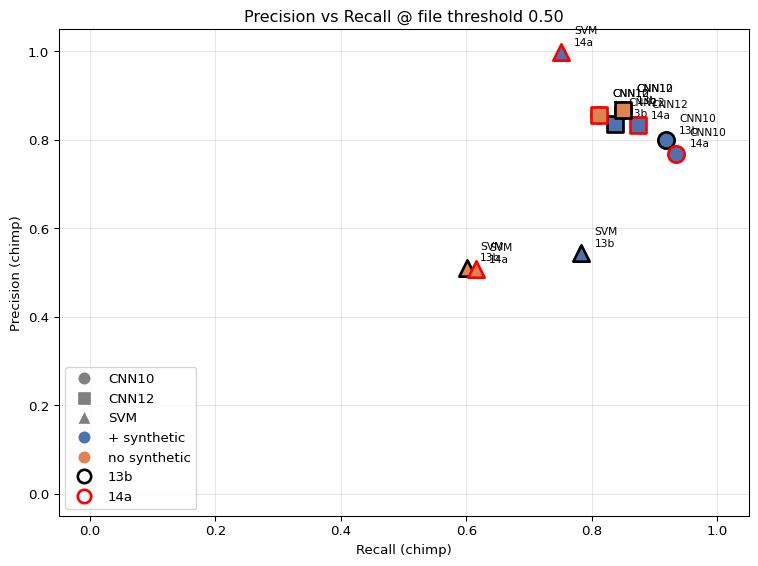

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

markers = {"CNN10": "o", "CNN12": "s", "SVM": "^"}
colors = {"Yes": "#4C72B0", "No": "#DD8452"}
edge_colors = {"13b": "black", "14a": "red"}

for _, row in results_df.iterrows():
    ax.scatter(
        row["recall-macro"], row["precision-macro"],
        marker=markers[row["model"]],
        c=colors[row["synthetic"]],
        edgecolors=edge_colors[row["test_set"]],
        s=150, linewidths=2, zorder=5
    )
    ax.annotate(
        f"{row['model']}\n{row['test_set']}",
        (row["recall-macro"], row["precision-macro"]),
        textcoords="offset points",
        xytext=(10, 5), fontsize=8
    )

legend_elements = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="gray", markersize=10, label="CNN10"),
    Line2D([0], [0], marker="s", color="w",
           markerfacecolor="gray", markersize=10, label="CNN12"),
    Line2D([0], [0], marker="^", color="w",
           markerfacecolor="gray", markersize=10, label="SVM"),
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="#4C72B0", markersize=10, label="+ synthetic"),
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="#DD8452", markersize=10, label="no synthetic"),
    Line2D([0], [0], marker="o", color="w",
           markeredgecolor="black", markersize=10,
           markeredgewidth=2, label="13b"),
    Line2D([0], [0], marker="o", color="w",
           markeredgecolor="red", markersize=10,
           markeredgewidth=2, label="14a"),
]
ax.legend(handles=legend_elements, loc="lower left")
ax.set_xlabel("Recall (chimp)")
ax.set_ylabel("Precision (chimp)")
ax.set_title(f"Precision vs Recall @ file threshold {FILE_THRESHOLD:.2f}")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Score Distributions

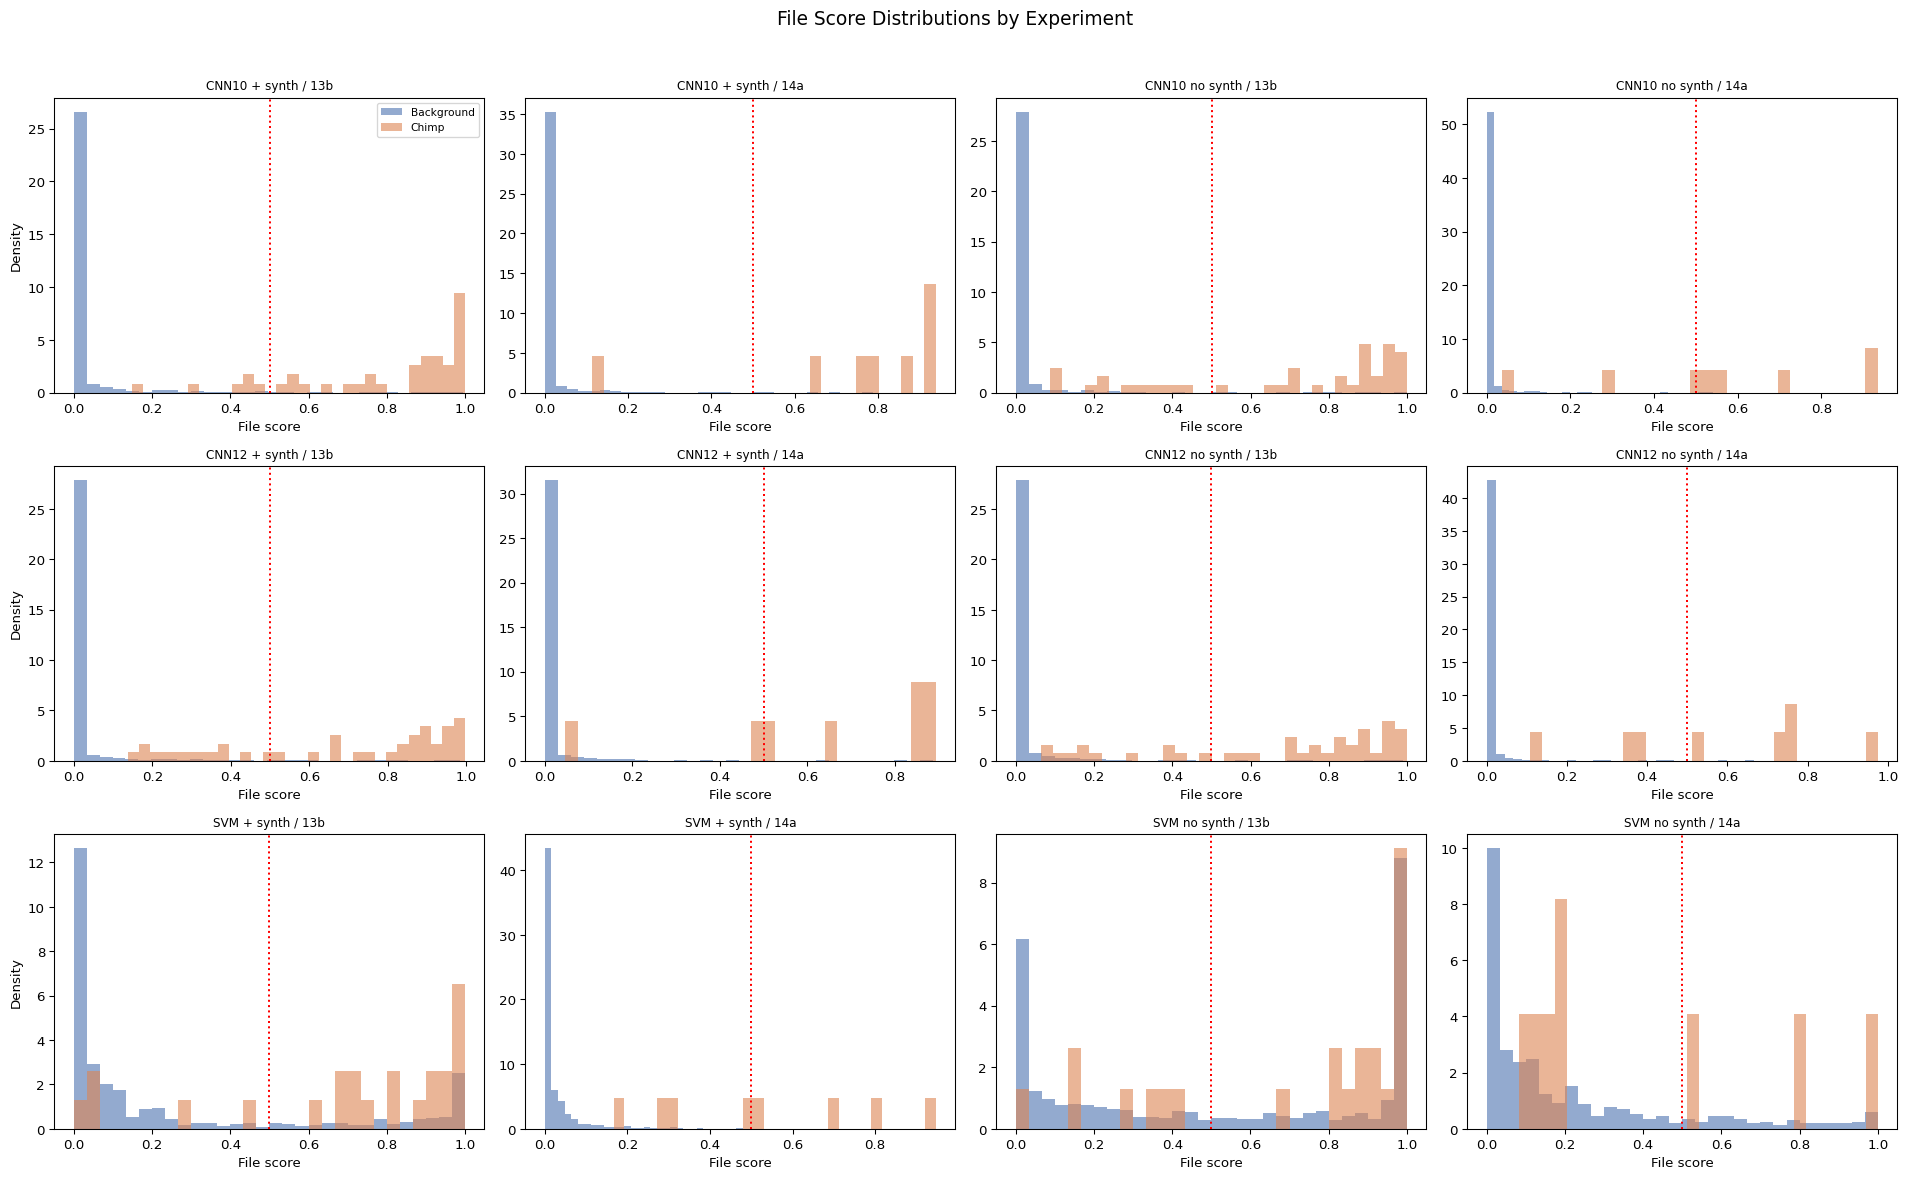

In [9]:
n_cols = 4
n_rows = int(np.ceil(len(raw_data) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

for idx, (name, data) in enumerate(raw_data.items()):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row][col]

    prob_pos = data["prob_pos"]
    y_true = data["y_true"]

    ax.hist(
        prob_pos[y_true == 0], bins=30, alpha=0.6,
        label="Background", density=True, color="#4C72B0"
    )
    ax.hist(
        prob_pos[y_true == 1], bins=30, alpha=0.6,
        label="Chimp", density=True, color="#DD8452"
    )
    ax.axvline(FILE_THRESHOLD, color="red", linestyle=":", linewidth=1.5)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("File score")
    if col == 0:
        ax.set_ylabel("Density")
    if idx == 0:
        ax.legend(fontsize=8)

for idx in range(len(raw_data), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].axis("off")

plt.suptitle("File Score Distributions by Experiment", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Confusion Matrices

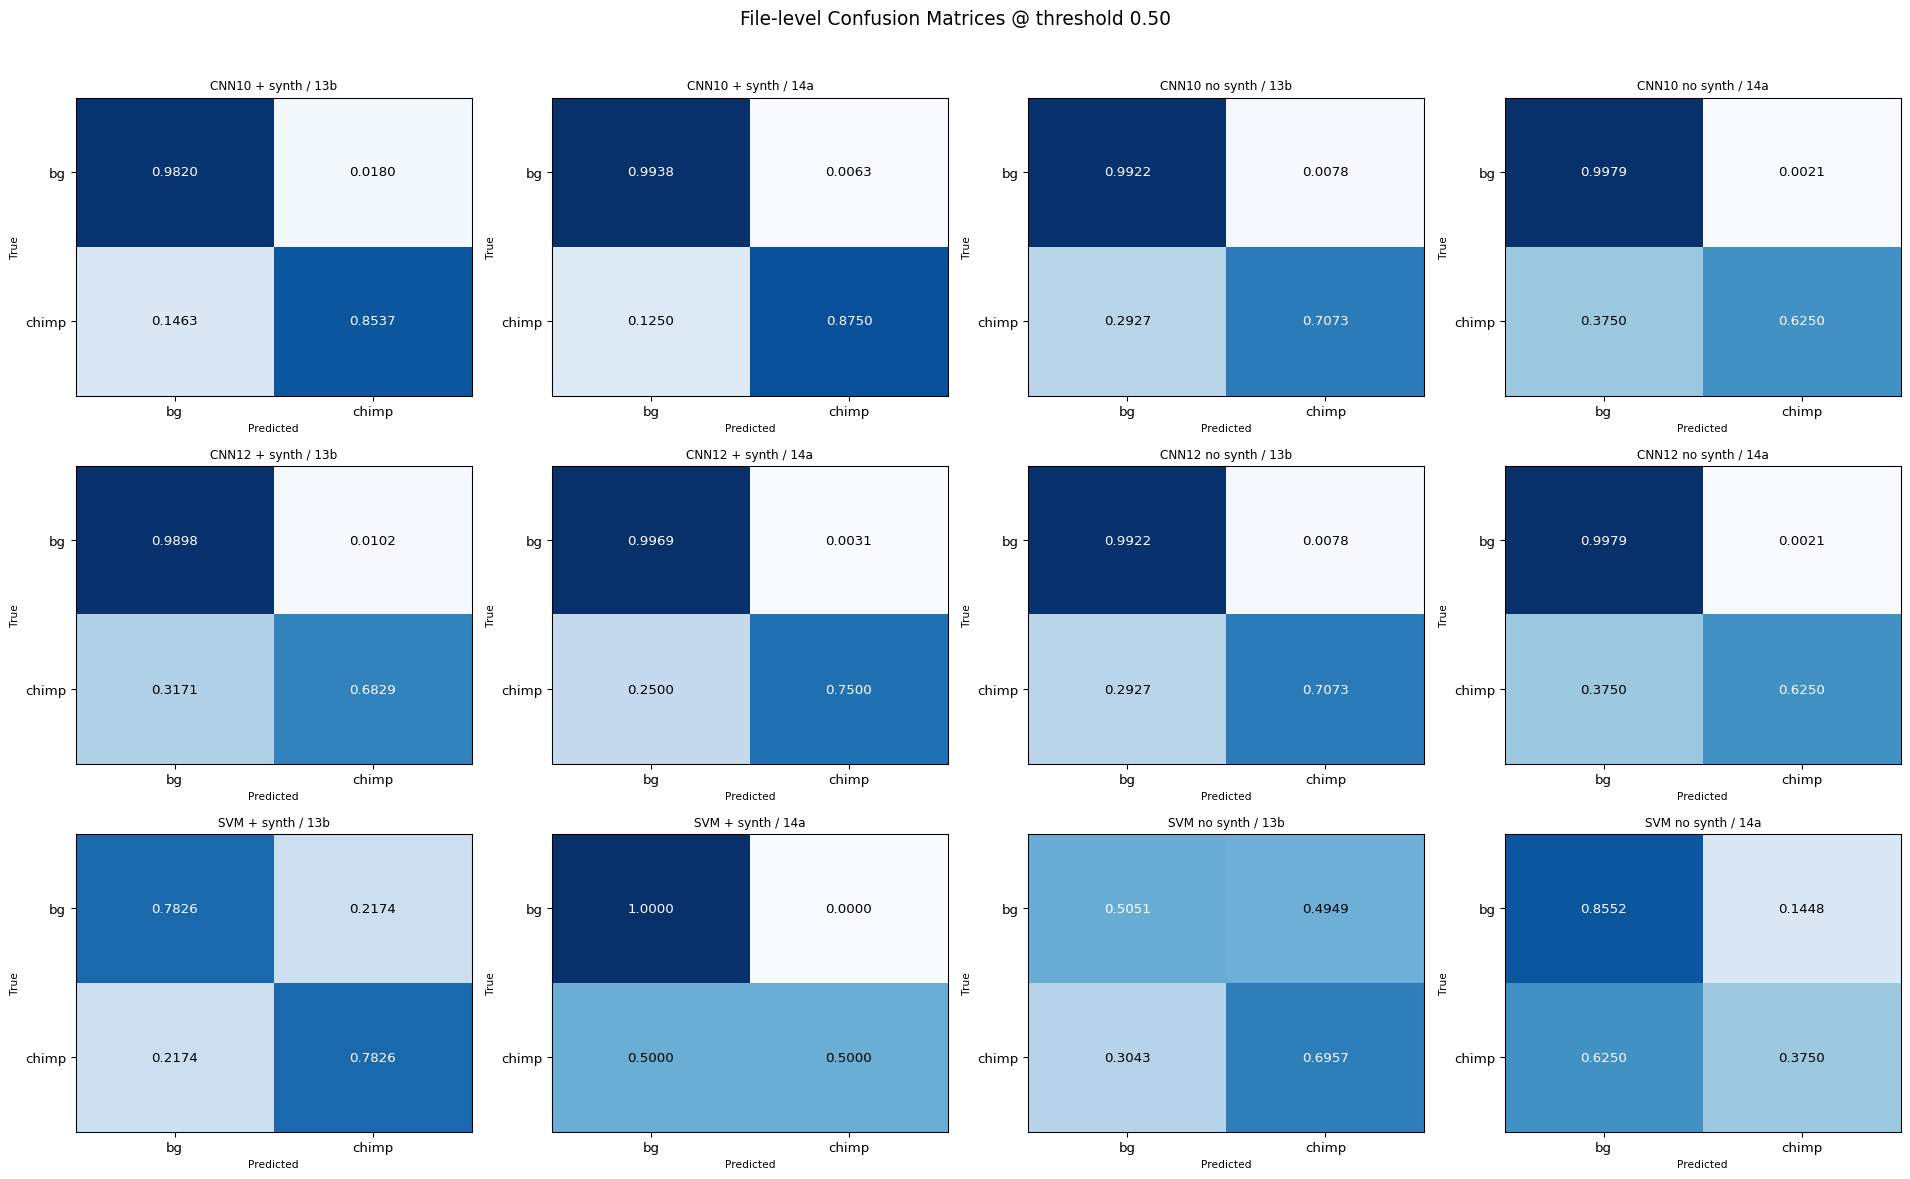

In [10]:
n_cols = 4
n_rows = int(np.ceil(len(raw_data) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

for idx, (name, data) in enumerate(raw_data.items()):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row][col]

    preds = data["preds"]
    y_true = data["y_true"]
    cm = confusion_matrix(y_true, preds, normalize="true")

    # Normalize by row (true label) → each row sums to 1
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap="Blues", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["bg", "chimp"])
    ax.set_yticklabels(["bg", "chimp"])
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)
    ax.set_title(name, fontsize=9)

    for i in range(2):
        for j in range(2):
            val = cm_norm[i, j]
            raw = cm[i, j]
            color = "white" if val > 0.5 else "black"
            ax.text(
                j, i, "{:0.4f}".format(val),
                ha="center", va="center",
                color=color, fontsize=10
            )

for idx in range(len(raw_data), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].axis("off")

plt.suptitle(
    f"File-level Confusion Matrices @ threshold {FILE_THRESHOLD:.2f}",
    fontsize=14,
    y=1.02,
    )
plt.tight_layout()
plt.show()